In [1]:
import numpy as np
import matplotlib.pyplot as plt

from srwave.radiation_source import *
from srwave.opt_elements import *
from srwave.beamlines import *
from srwave.rad_plots import *
from srwave.utils import *

spectrum

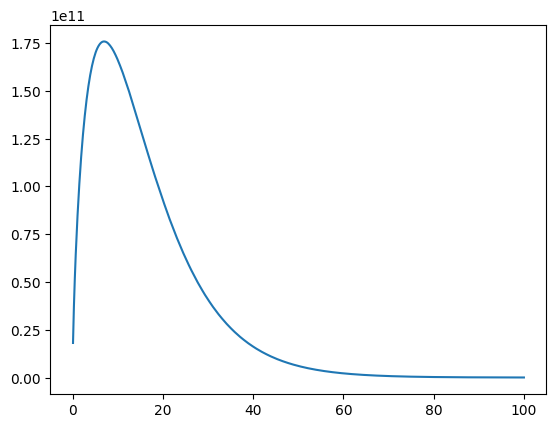

In [8]:
e = np.linspace(0.1,100,500)*1e3

SR = SynchrotronRadiation(energy=e,d=10,x=0,y=0,field={'BM':[1.4,3]})

arrI, [rangee] = SR.calc_intensity(coords='e',energy=0,X=0,Y=0,polarization='total',intType='SE')

plt.plot(e*1e-3,arrI)
plt.show()

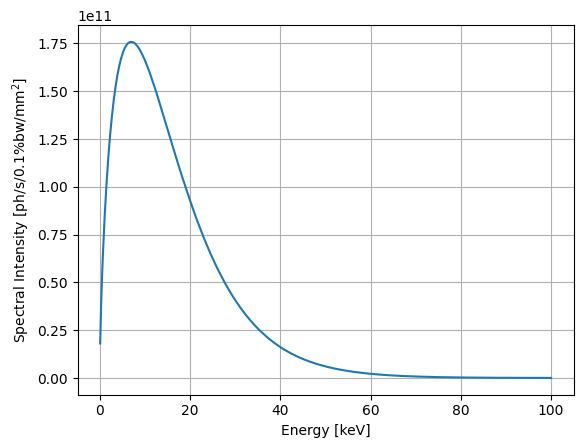

In [9]:
e = np.linspace(0.1,100,500)*1e3

SR = SynchrotronRadiation(energy=e,d=10,x=0,y=0,field={'BM':[1.4,3]})

ax = plt.subplot()
plot_spectrum(SR,energy=0,X=0,Y=0,ax=ax,show=False)

plt.show()

flux density

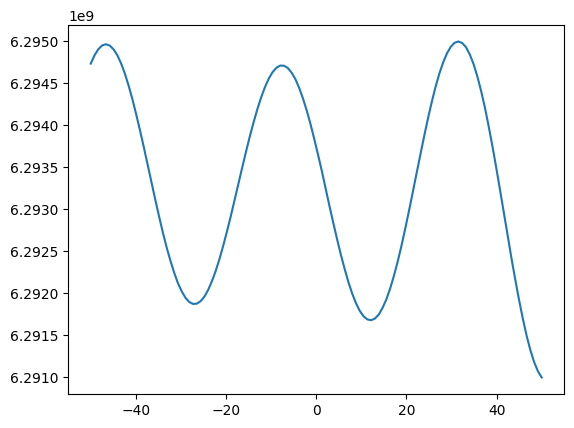

In [11]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

SR = SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,field={'BM':[0.5642,3]})

arrI, [rangex] = SR.calc_intensity(coords='x',energy=0,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrI)
plt.show()

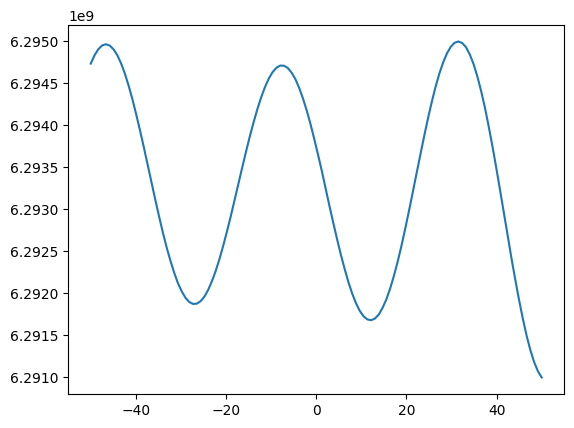

In [12]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

SR = SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,field={'BM':[0.5642,3]})

plot_wfr_inten(SR,coords='x',energy=Eph,X=0,Y=0,intType='SE')

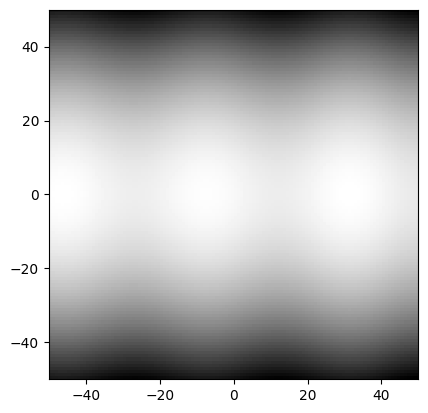

In [13]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

SR = SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,field={'BM':[0.5642,3]})

plot_wfr_inten(SR,coords='xy',energy=Eph,X=0,Y=0,intType='SE')

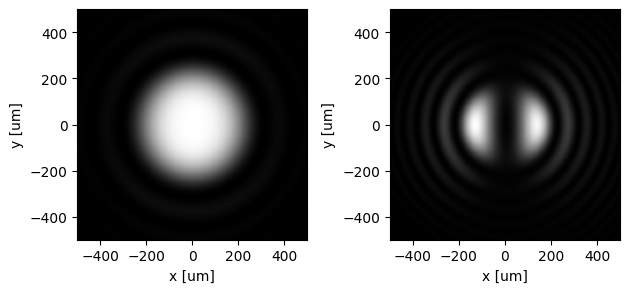

In [23]:
w = np.linspace(-5e-4,5e-4,200)

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

for ax, Eph in zip([ax1,ax2],[569.7804832,1139.5609663]):

    SR = SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,field={'Und':[50e-3,20,calc_B(2,50e-3)]})

    arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=SR.mesh.eStart,X=0,Y=0,polarization='total',intType='SE')
    xi, xf, nx, yi, yf, ny = *rangex, *rangey
    arrI = np.array(arrI).reshape(ny,nx)

    limits = np.array([xi,xf,yi,yf])*1e6
    ax.imshow(arrI,cmap='gray',extent=limits)
    ax.set_ylabel('y [um]')
    ax.set_xlabel('x [um]')

plt.tight_layout()
plt.show()

fluence

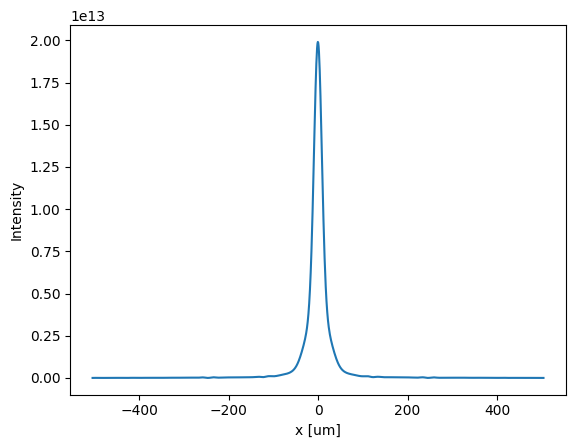

In [14]:
e = np.linspace(10,50,21)*1e3
w = np.linspace(-50,50,120)*1e-6
SR = PinholeLine(energy=e,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

plot_wfr_inten(SR,coords='x',energy=Eph,X=0,Y=0,intType='SE Fluence',xlabel='x [um]',ylabel='Intensity',show=True)

electric field

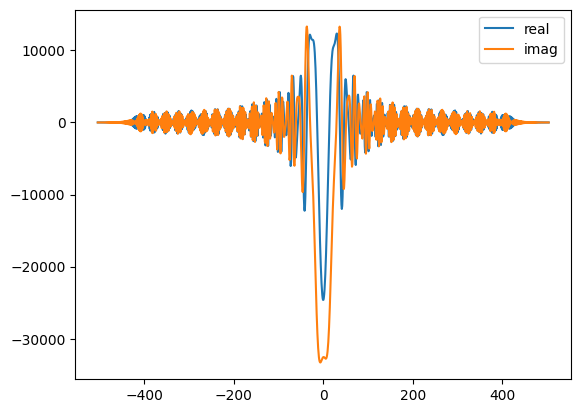

In [15]:
w = np.linspace(-50,50,120)*1e-6
SR = PinholeLine(energy=17.5e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

arrReE, [rangex] = SR.calc_electric_field(part='re',coords='x',energy=0,X=0,Y=0,polarization='total')
arrImE, [rangex] = SR.calc_electric_field(part='im',coords='x',energy=0,X=0,Y=0,polarization='total')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrReE,label='real')
plt.plot(x,arrImE,label='imag')
plt.legend()
plt.show()

phase

In [17]:
w = np.linspace(-50,50,120)*1e-6
SR = SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,field={'BM':[0.5642,3]})

arrP, [rangex, rangey] = SR.calc_electric_field(part='phase',coords='xy',energy=0,X=0,Y=0)
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrP = np.array(arrP).reshape(ny,nx)

limits = np.array([xi,xf,yi,yf])*1e6

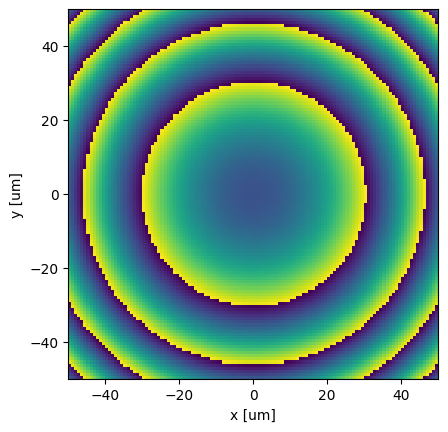

In [20]:
plt.imshow(arrP,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

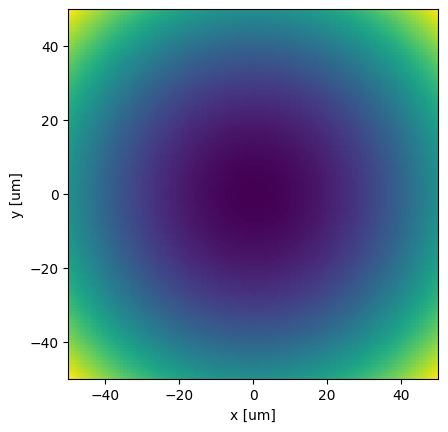

In [22]:
arrP_unw = SR.unwrap_phase(arrP)

plt.imshow(arrP_unw,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

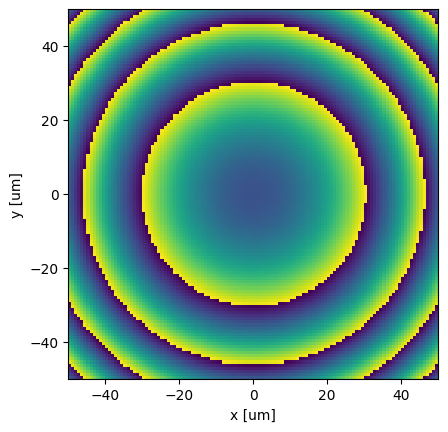

In [23]:
arrP_w = SR.wrap_phase(arrP_unw)

plt.imshow(arrP_w,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

construction of beamline and extraction of intensity

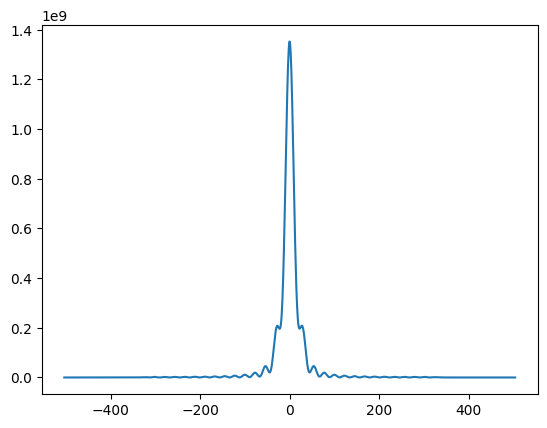

In [24]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

SR = SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,field={'BM':[0.5642,2]})
filtro = DissipationFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = Aperture(apert,apert)
aper.prop_params['ra'] = 10.0
screen = Drift(dist=10)
bl = Beamline(line=[filtro,aper,screen])
SR.propagateWfr(beamline=bl)

arrIx, [rangex] = SR.calc_intensity(coords='x',energy=Eph,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrIx)
plt.show()

gaussian fitting

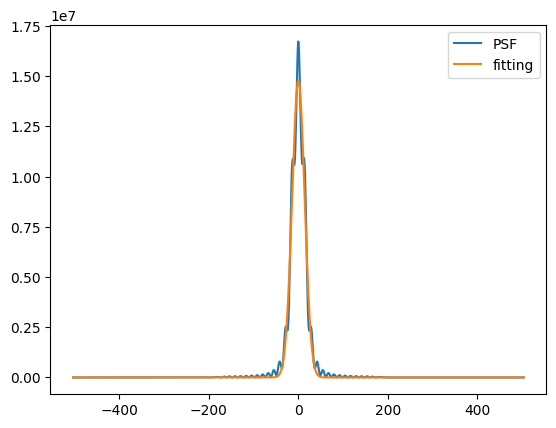

In [13]:
w = np.linspace(-50,50,120)*1e-6
SR = PinholeLine(energy=40e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

arrIx, [rangex] = SR.calc_intensity(coords='x',energy=Eph,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

params = gaussian_fit(x,arrIx)

plt.plot(x,arrIx,label='PSF')
plt.plot(x,gaussian(x,*params),label='fitting')
plt.legend()
plt.show()

fixed beamlines

FWHM:
 - x: 26.07
 - y: 26.08


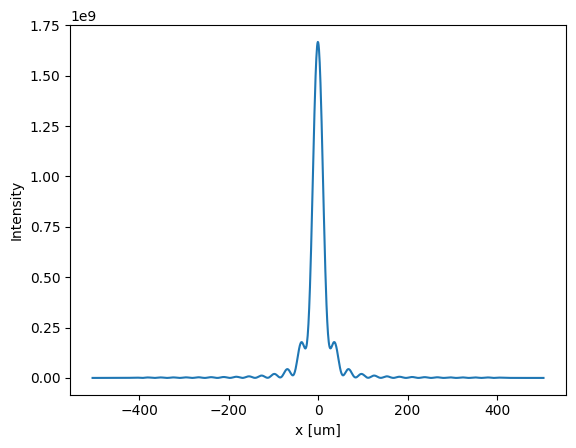

In [25]:
w = np.linspace(-50,50,120)*1e-6
SR = PinholeLine(energy=17.5e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

print(f"FWHM:\n - x: {fwhm_SR(SR,coord='x',energy=Eph,X=0,Y=0):.2f}\n - y: {fwhm_SR(SR,coord='y',energy=Eph,X=0,Y=0):.2f}")
plot_wfr_inten(SR,coords='x',energy=Eph,X=0,Y=0,xlabel='x [um]',ylabel='Intensity',show=True)

FWHM:
 - x: 0.44
 - y: 0.86


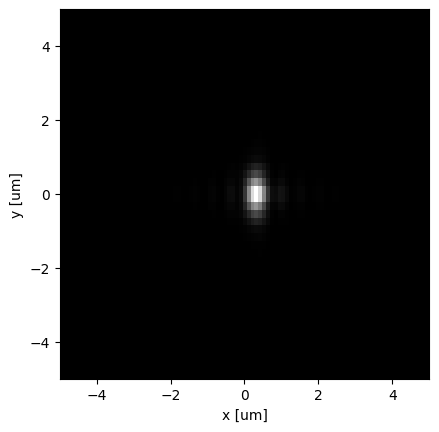

In [27]:
w = np.linspace(-3,3,200)*1e-3
SR = ToroidalMirrorLine(energy=11e3,d=17,D=17,x=w,y=w,apertx=4e-3,aperty=4e-3,
                        ang=18.78e-3,tang_len=0.22,sag_len=0.008,R_tang=905.271,
                        R_sag=0.3192)

print(f"FWHM:\n - x: {fwhm_SR(SR,coord='x',energy=Eph,X=0,Y=0):.2f}\n - y: {fwhm_SR(SR,coord='y',energy=Eph,X=0,Y=0):.2f}")
plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',
               xlim=(-5,5),ylim=(-5,5),xlabel='x [um]',ylabel='y [um]')

FWHM:
 - x: 0.44
 - y: 0.86


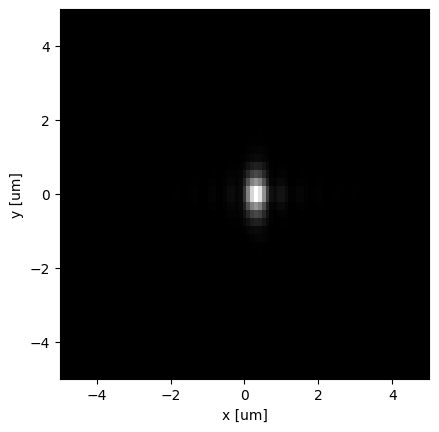

In [29]:
SR = Carcara(apertx=5e-3,aperty=5e-3)

print(f"FWHM:\n - x: {fwhm_SR(SR,coord='x',energy=Eph,X=0,Y=0):.2f}\n - y: {fwhm_SR(SR,coord='y',energy=Eph,X=0,Y=0):.2f}")
plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',
               xlim=(-5,5),ylim=(-5,5),xlabel='x [um]',ylabel='y [um]')

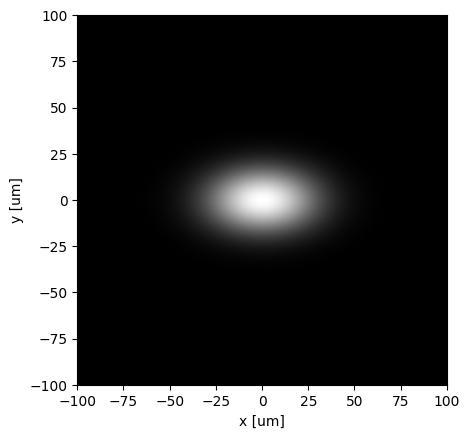

In [31]:
SR = Carcara(apertx=5e-3,aperty=5e-3)

plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',intType='ME',
               xlabel='x [um]',ylabel='y [um]',xlim=(-100,100),ylim=(-100,100))

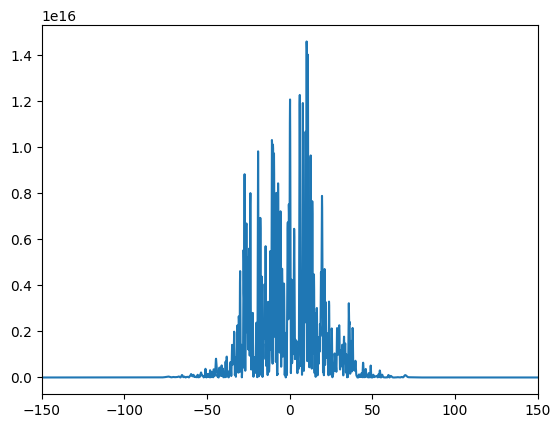

In [2]:
SR = Carcara(apertx=5e-3,aperty=5e-3,mirror_error='meas')

plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))

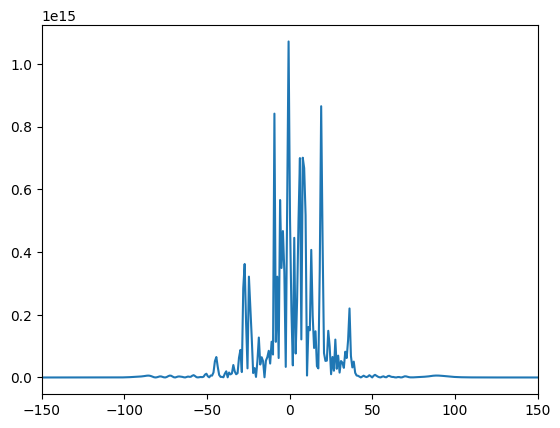

In [3]:
SR = Carcara(apertx=1e-3,aperty=1e-3,mirror_error='meas')

plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))

caustic

In [5]:
Eph = 17.5e3
w = np.linspace(-50,50,120)*1e-6
apert = 5e-6

SR = SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,field={'BM':[0.5642,2]})
filtro = DissipationFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = Aperture(apert,apert)
aper.prop_params['ra'] = 10.0
# screen = Drift(dist=d)
# bl = Beamline(line=[filtro,aper,screen])
bl = Beamline(line=[filtro,aper])
SR.propagateWfr(beamline=bl)

True

In [6]:
distances = np.linspace(2,10,9)

arrsI, ranges = caustic(SR,dists=distances,coord='x',energy=Eph,X=0,Y=0)

limits = [distances[0],distances[-1],ranges[0][0]*1e6,ranges[0][1]*1e6]

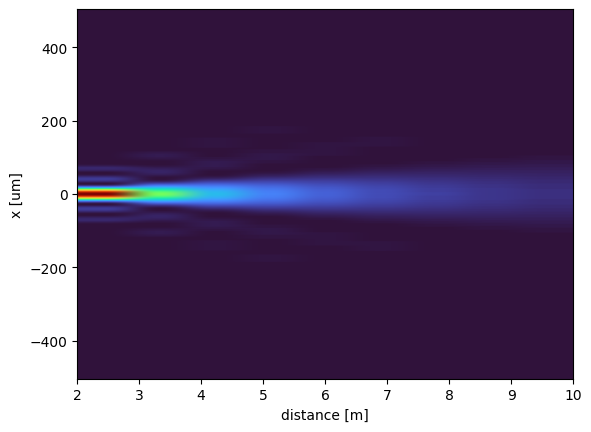

In [8]:
plt.imshow(arrsI,extent=limits,aspect='auto',cmap='turbo')
plt.ylabel('x [um]')
plt.xlabel('distance [m]')
plt.show()